## Garganta del Dino cave, central Ecuador

In [1]:
'''
Created on Mon Oct 28 2024 09:49:00
Script after EGU 2024
Check https://linked.earth/paleoTS/ PaleoTS 
'''
## Import libraries
import pyleoclim as pyleo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1.1 Load Speleothems

In [2]:
'''
Venezuela
'''
veaj13 = pd.read_csv('../data/veaj.tab', delimiter="\t")
ts_veaj13 = pyleo.Series(
    time=veaj13.iloc[:, 5]*1000,
    value=veaj13.iloc[:, 7],
    time_name="Age",
    time_unit="years BP",
    value_name= r'$\delta^{13}$C',
    value_unit="‰ VPDB",
    label="Alfredo Jahn cave")

veaj18 = pd.read_csv('../data/veaj.tab', delimiter="\t")
ts_veaj18 = pyleo.Series(
    time=veaj18.iloc[:, 5]*1000,
    value=veaj18.iloc[:, 6],
    time_name="Age",
    time_unit="years BP",
    value_name= r'$\delta^{18}$O',
    value_unit="‰ VPDB",
    label="Alfredo Jahn cave")


'''
Colombia
'''








'''
Ecuador
'''
## Garganta del Dino cave
din218 = pd.read_table('../data/GDD1_d18O_CopraSpline_2mm.txt')
ts_din218 = pyleo.Series(
    time =  din218.iloc[:, 0] , 
    value = din218.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'years BP',
    value_name = r'$\delta^{18}$O',
    value_unit = '‰ VPDB',
    label = 'Dino cave', verbose=False)

din213 = pd.read_table('../data/GDD1_d13C_CopraSpline_2mm.txt')
ts_din213 = pyleo.Series(
    time =  din213.iloc[:, 0] , 
    value = din213.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'years BP',
    value_name = r'$\delta^{13}$C',
    value_unit = '‰ VPDB',
    label = 'Dino cave', verbose=False)


din518 = pd.read_table('../data/GDD1_d18O_CopraSpline_5mm.txt')
ts_din518 = pyleo.Series(
    time =  din518.iloc[:, 0] , 
    value = din518.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'years BP',
    value_name = r'$\delta^{18}$O',
    value_unit = '‰ VPDB',
    label = 'Dino cave-5mm', verbose=False)

din513 = pd.read_table('../data/GDD1_d13C_CopraSpline_5mm.txt')
ts_din513 = pyleo.Series(
    time =  din513.iloc[:, 0] , 
    value = din513.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'years BP',
    value_name = r'$\delta^{13}$C',
    value_unit = '‰ VPDB',
    label = 'Dino cave-5mm', verbose=False)

## Santiago cave
sant = pd.read_table('../data/santiago2012.txt', comment='#')
sant.head()
ts_sant = pyleo.Series(
    time=sant["age_calBP"],
    value=sant["d18OcarbVPDB"],
    time_name="Age",
    time_unit="years BP",
    value_name= r'$\delta^{18}$O',
    value_unit= '‰ VPDB',
    label="Santiago cave")

'''
Peru
'''
## Tigre Perdido, Peru Alt+Shift in Notepad
tig = pd.read_table(r'../data/tigre-perdido2008.txt', comment='#')
ts_tig = pyleo.Series(
    time=tig["Age"],
    value=tig["d18O PDB"],
    time_name="Age",
    time_unit="years BP",
    value_name=r'$\delta^{18}$O',
    value_unit='‰ VPDB',
    label="Tigre cave")

#ts_tigmh = ts_tig.sel(time=slice(4000,8000))
#ts_tigmh.plot(marker='o', color='gray')




'''
Indonesia
'''
## Tangga cave, 2024.03.16
tang = pd.read_table(r'../data/tangga2018d18o.txt', comment='#')
ts_tang = pyleo.Series(
    time=tang["age_calkaBP"]*1000,
    value=tang["d18O-raw"],
    time_name="Age",
    time_unit="years BP",
    value_name=r'$\delta^{18}$O',
    value_unit='‰ VPDB',
    label="Tangga cave")








Time axis values sorted in ascending order
Time axis values sorted in ascending order
Time axis values sorted in ascending order
NaNs have been detected and dropped.
Time axis values sorted in ascending order
Time axis values sorted in ascending order


<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰]'>

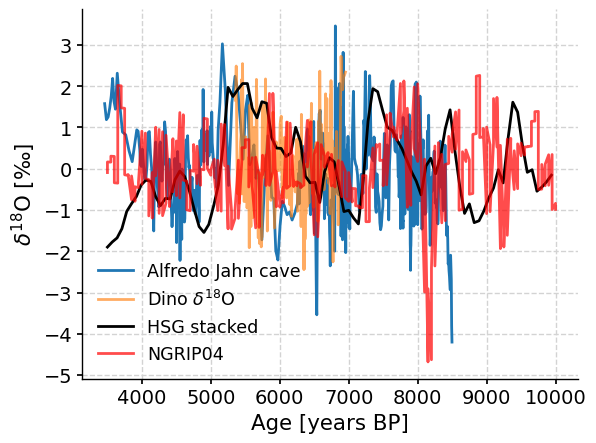

In [57]:
fig, ax=plt.subplots()
ts_veaj18.detrend().standardize().plot(ax=ax)
ts_din218.detrend().standardize().plot(ax=ax, label='Dino $\delta^{18}$O', alpha=0.65)
ts_bondstack.sel(time=slice(3500, 10000)).detrend().standardize().plot(ax=ax, color='k')
ts_ngrip04.sel(time=slice(3500, 10000)).detrend().standardize().plot(ax=ax, color='red', alpha=0.7)


<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰]'>

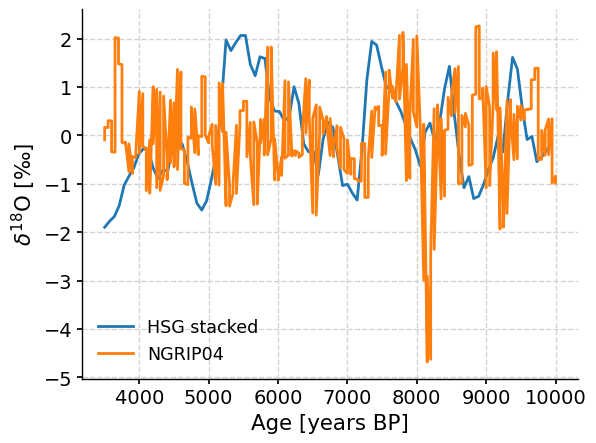

In [59]:
fig, ax=plt.subplots()
ts_bondstack.sel(time=slice(3500, 10000)).detrend().standardize().plot(ax=ax)
ts_ngrip04.sel(time=slice(3500, 10000)).detrend().standardize().plot(ax=ax)

In [60]:
ts_bondstack.dashboard()

AttributeError: 'Series' object has no attribute 'dashboard'

### Two Y-axis

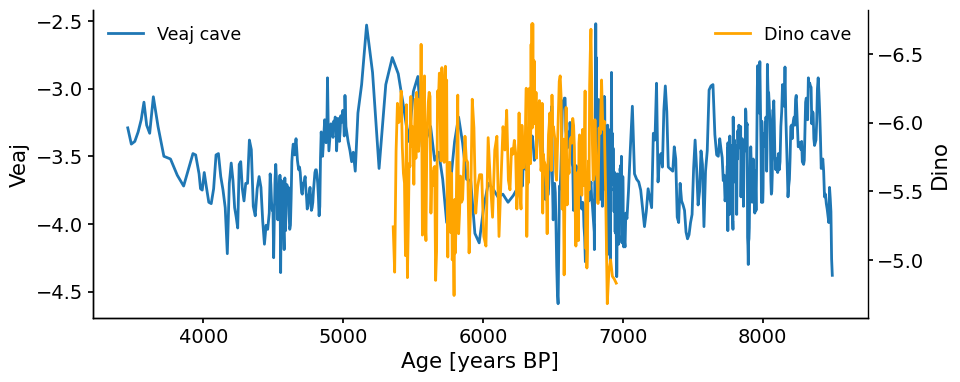

In [39]:
'''
Raw data from Dino and Veaj cave
'''
# Plot the first time series
fig, ax1 = ts_veaj18.plot(label='Veaj cave')
ax1.grid(False)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  # Create a twin axes that shares the same x-axis

# Plot the second time series on the twin axes
ts_din218.plot(ax=ax2, label='Dino cave', zorder=99, color='orange', invert_yaxis=True)
ax2.grid(False)

# Set labels for the y-axes to differentiate them
ax1.set_ylabel('Veaj')
ax2.set_ylabel('Dino')

# Set the legend for both y-axes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Make sure all spines (frame edges) are visible
plt.gca().spines['right'].set_visible(True)

# Show the plot
fig.show()

## KEY1

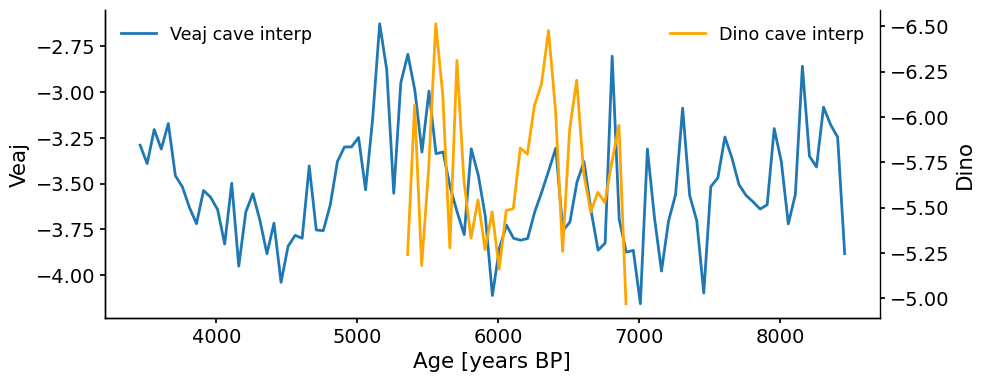

In [42]:
'''
Smoothed Dino and Veaj cave
'''
# Plot the first time series
fig, ax1 = ts_veaj18.interp(step=50).plot(label='Veaj cave interp')
ax1.grid(False)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  # Create a twin axes that shares the same x-axis

# Plot the second time series on the twin axes
ts_din218.interp(step=50).plot(ax=ax2, label='Dino cave interp', zorder=99, color='orange', invert_yaxis=True)
ax2.grid(False)

# Set labels for the y-axes to differentiate them
ax1.set_ylabel('Veaj')
ax2.set_ylabel('Dino')

# Set the legend for both y-axes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Make sure all spines (frame edges) are visible
plt.gca().spines['right'].set_visible(True)

# Show the plot
fig.show()

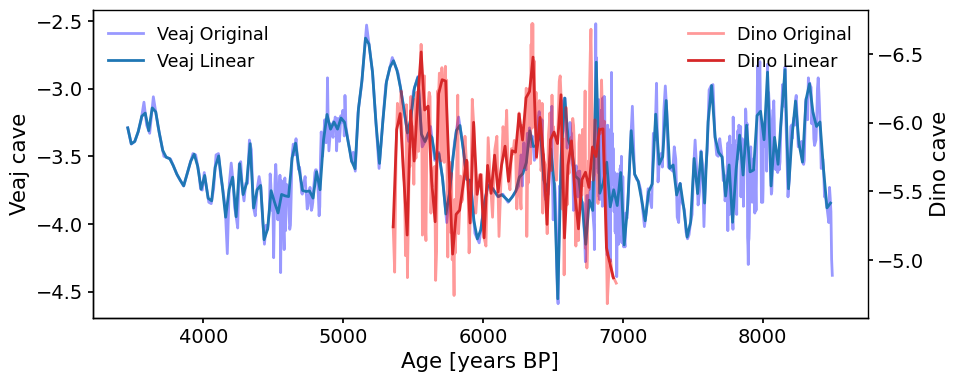

In [35]:
# Plot the first time series
fig, ax1 = ts_veaj18.plot(label='Veaj Original', color='blue', alpha=0.4)
ts_veaj18.interp(step=25).plot(ax=ax1, label='Veaj Linear', color='tab:blue')

# Remove grid lines on the first axis
ax1.grid(False)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  # Create a twin axes that shares the same x-axis

# Plot the second time series on the twin axes
ts_din218.plot(ax=ax2, label='Dino Original', zorder=99, color='red', alpha=0.4, invert_yaxis=True)
ts_din218.interp(step=25).plot(ax=ax2, label='Dino Linear', zorder=99, color='tab:red')

# Remove grid lines on the second axis
ax2.grid(False)

# Set labels for the y-axes to differentiate them
ax1.set_ylabel('Veaj cave')
ax2.set_ylabel('Dino cave')

# Set the legend for both y-axes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Make sure all spines (frame edges) are visible
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['left'].set_visible(True)

# Show the plot
fig.show()


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>)

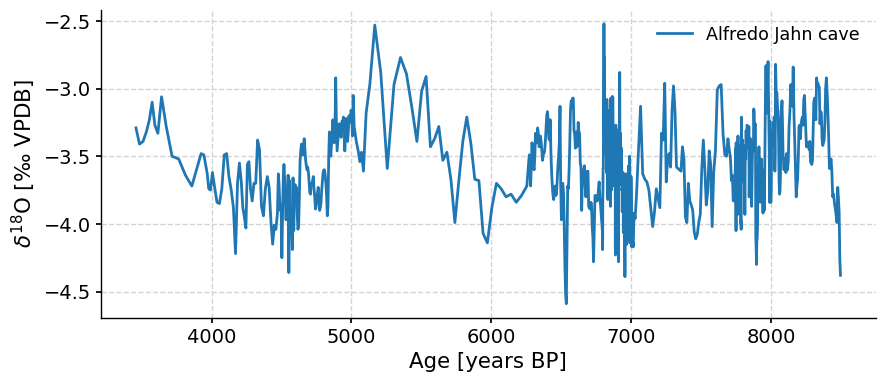

In [78]:
ts_veaj18.plot()

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='Scale [yrs]'>)

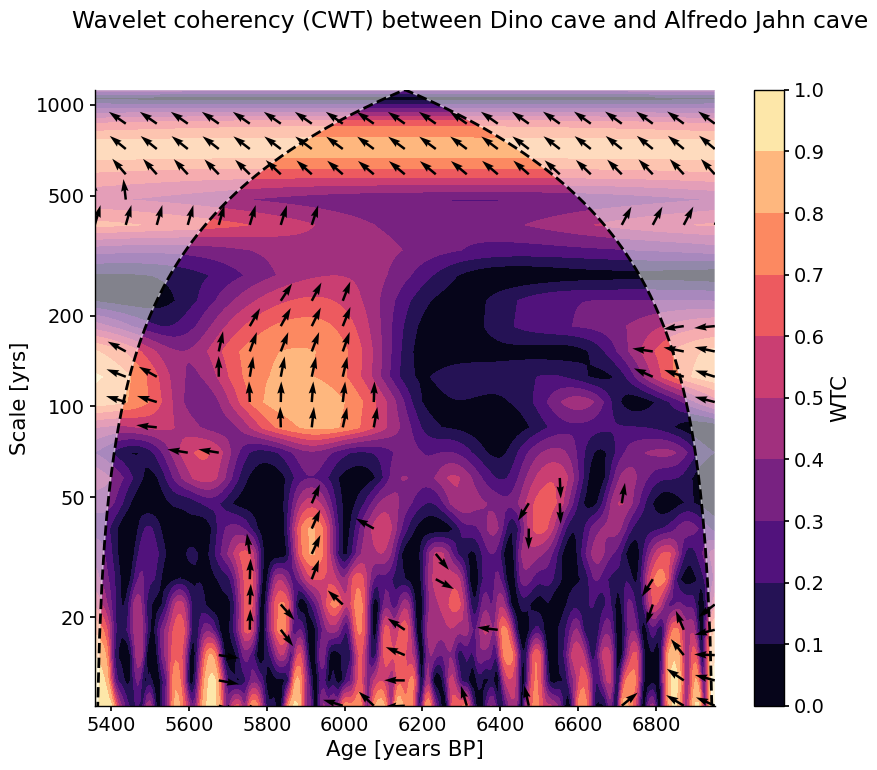

In [77]:
ts_din218.wavelet_coherence(ts_veaj18).plot()

In [79]:
#Seems to have a good anticorrelation with veaj cave, also check the excel file

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Period [years]', ylabel='PSD'>)

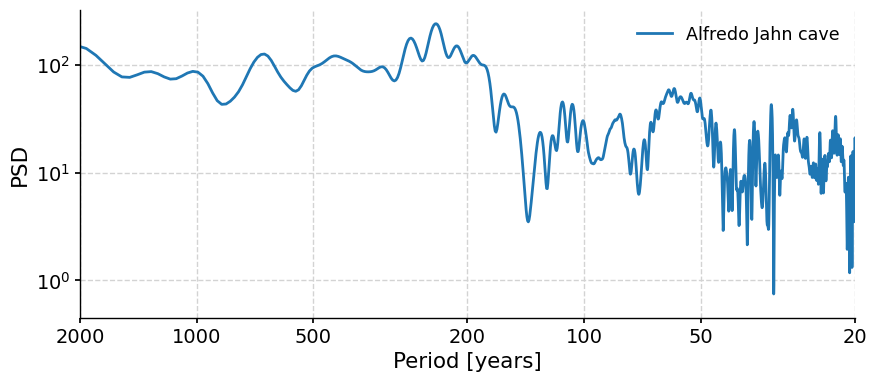

In [81]:
ts_veaj18.spectral(method='lomb_scargle').plot()

<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

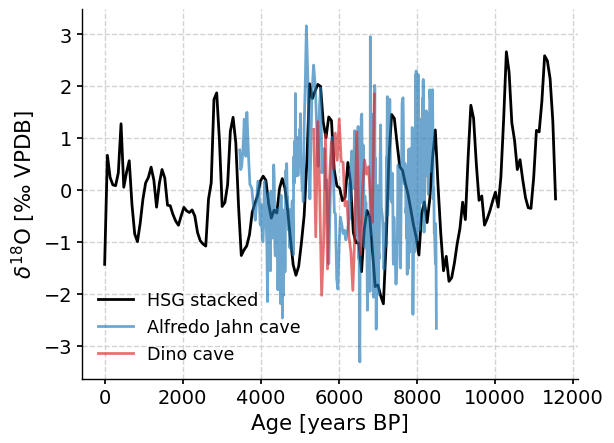

In [98]:
fig, ax=plt.subplots()
ts_bondstack.detrend().standardize().plot(ax=ax, color='k')
ts_veaj18.interp(step=1).standardize().plot(ax=ax, color='tab:blue', alpha=0.65)
ts_din218.interp(step=50).standardize().plot(ax=ax, color='tab:red', alpha=0.65)


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Period [years]', ylabel='PSD'>)

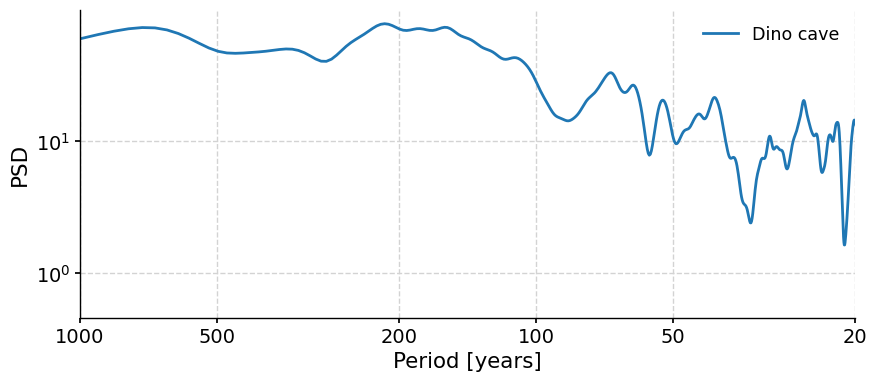

In [89]:
ts_din218.spectral(method='lomb_scargle').plot()

## 1.2 Load Ice cores

In [48]:
## NGRIP 2004, from Fig. 1 in 040_Mosblech et al.2012
ngrip04 = pd.read_table(r'../data/NGRIP2004.txt', comment='#')
ts_ngrip04 = pyleo.Series(
    time=ngrip04.iloc[:, 0],
    value=ngrip04.iloc[:, 1],
    time_name="Age",
    time_unit="years BP",
    value_name=r'$\delta^{18}$O',
    value_unit="‰",
    label="NGRIP04")

Time axis values sorted in ascending order


## 1.3. Load Holocene records of drift-ice

In [43]:
## Bond events: North Atlantic Holocene Drift Ice Proxy Data 
# https://commons.wikimedia.org/wiki/File:BondEvents-stacked-bond2001-labeled-en.svg
# ncei.noaa.gov/pub/data/paleo/contributions_by_author/bond2001/bond2001.txt

## Bond VM29-191
bond = pd.read_table(r'../data/bond2001b.txt', comment='#')
ts_bond = pyleo.Series(
    time=bond["age"],
    value=bond["HSG"],
    time_name="Age",
    time_unit="years BP",
    value_name="HSG",
    value_unit="%",
    label="VM29-191")

## Bond stacked and smoothed
# Try different encodings until one works
bond_file = r'../data/bond2001.txt'

# Try different encodings until one works
try:
    bondstack = pd.read_table(bond_file, comment='#', encoding='utf-8', delim_whitespace=True)
except UnicodeDecodeError:
    try:
        bondstack = pd.read_table(bond_file, comment='#', encoding='ISO-8859-1', delim_whitespace=True)
    except UnicodeDecodeError:
        try:
            bondsstack = pd.read_table(bond_file, comment='#', encoding='cp1252', delim_whitespace=True)
        except UnicodeDecodeError:
            bondstack = pd.read_table(bond_file, comment='#', encoding='utf-16', delim_whitespace=True)

ts_bondstack = pyleo.Series(
    time=bondstack["carb"],
    value=bondstack["age.4"],
    time_name="Age",
    time_unit="years BP",
    value_name="HSG",
    value_unit="%",
    label="HSG stacked")



## Leduc et al.2007 https://www.ncei.noaa.gov/pub/data/paleo/paleocean/sediment_files/complete/md2-2529-tab.txt
# Define file paths using os.path.join
leduc_file = r'../data/md2-2529-tab.txt'
# Try different encodings if the first one doesn't work
encodings = ['utf-8', 'latin1', 'iso-8859-1', 'cp1252']
for encoding in encodings:
    try:
        leduc = pd.read_table(
            leduc_file, 
            delimiter="\t", 
            comment='#', 
            encoding=encoding,
            na_values=-999) # Treat -999 as NaN
        print(f"File read successfully with encoding: {encoding}")
        break
    except UnicodeDecodeError as e:
        print(f"Failed with encoding {encoding}: {e}")

ts_md2529grub = pyleo.Series(
    time =  leduc['yrBP '], #Has an extra space
    value = leduc['d18Og.rub'],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'δ18O',
    value_unit = '‰',
    label = 'δ18O Globigerinoides ruber', verbose=False)

ts_md2529d18O = pyleo.Series(
    time =  leduc['yrBP '], #Has an extra space
    value = leduc['d18Ow-s'],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'δ18O',
    value_unit = '‰',
    label = 'δ18O SMOW (water)', verbose=False)

ts_md2529sal = pyleo.Series(
    time =  leduc['yrBP '], 
    value = leduc['dd18O-smow'], #This is Fig.3 (red line) in PA031_Leduc et al.2007 Detrended from the previous one
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = r'$\delta^{18}$O',
    value_unit = '‰',
    label = 'EEP salinity', verbose=False)

ts_md2529sstuk37 = pyleo.Series(
    time =  leduc['yrBP '], 
    value = leduc['sst-uk37'],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'SST',
    value_unit = '°C',
    label = 'SST-uk37', verbose=False)

ts_md2529sstmgca = pyleo.Series(
    time =  leduc['yrBP '], 
    value = leduc['sst-mg/ca'],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'SST',
    value_unit = '°C',
    label = 'SST-Mg/Ca', verbose=False)

ts_md2529mgca = pyleo.Series(
    time =  leduc['yrBP '], 
    value = leduc['Mg/Ca'],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'Mg/Ca',
    value_unit = 'mmol/mol',
    label = 'Mg/Ca', verbose=False)






Time axis values sorted in ascending order
Time axis values sorted in ascending order
File read successfully with encoding: utf-8


## 1.4 Load Lake records

In [52]:
## Cariaco Basin Titanium, Venezuela
cariacoTi = pd.read_table(r'../data/cariaco_ti.txt', comment='#')
ts_cariacoTi = pyleo.Series(
    time=cariacoTi["Age"],
    value=cariacoTi["Ti"],
    time_name="Age",
    time_unit="years BP",
    value_name="Ti",
    value_unit="%",
    label="Cariaco Basin Ti")


## Cariaco Basin Reflectance, Peterson et al.2000 https://www.ncei.noaa.gov/pub/data/paleo/paleocean/sediment_files/complete/odp1002c-tab.txt
cariacoRef = pd.read_table(r'../data/odp1002c-tab.txt', comment='#', na_values=-999 )
ts_cariacoRef = pyleo.Series(
    time=cariacoRef["yrBP "],
    value=cariacoRef["ref%550"],
    time_name="Age",
    time_unit="years BP",
    value_name="Reflectance",
    value_unit="nm",
    label="Cariaco 550 nm reflectance")



## Pallcacocha Lake, Ecuador
pall = pd.read_table(r'../data/pallca_3.7-12.4ka.txt', header=None )
ts_pall = pyleo.Series(
    time=pall.iloc[:, 0],
    value=pall.iloc[:, 1],
    time_name="Age",
    time_unit="years BP",
    value_name="GrayScale",
    value_unit="%",
    label="Pallcacocha Lake")





NaNs have been detected and dropped.
Time axis values sorted in ascending order
Time axis values sorted in ascending order


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='Reflectance [nm]'>)

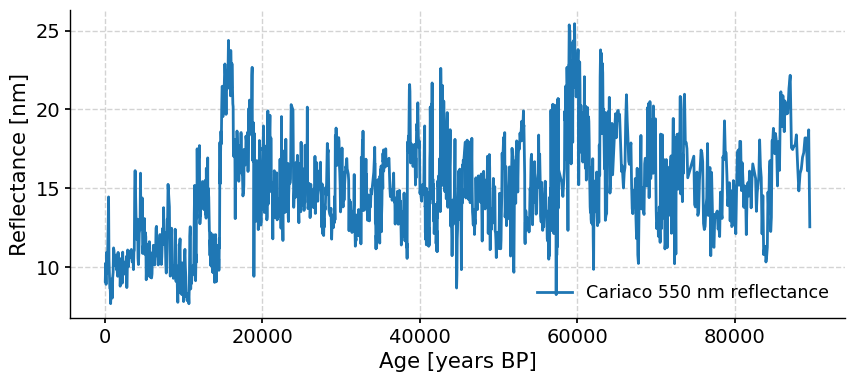

In [53]:
ts_odp1002c.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='GrayScale [%]'>)

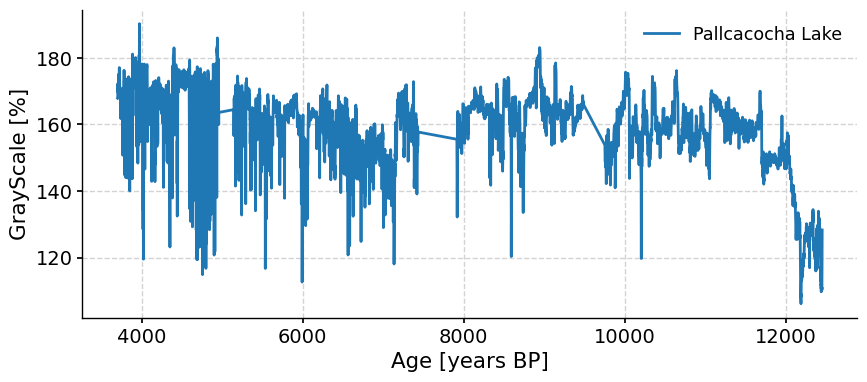

In [51]:
ts_pall.plot()

<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

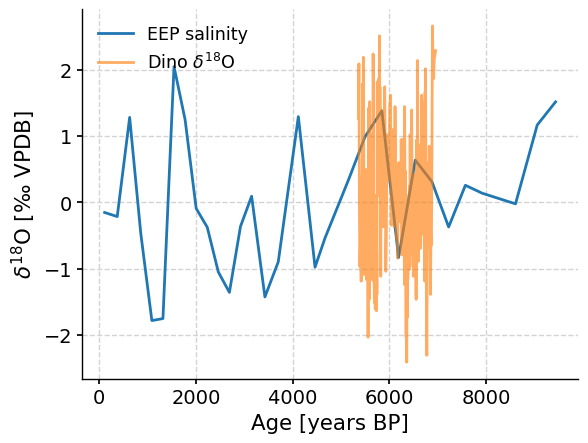

In [66]:
fig, ax=plt.subplots()
ts_md2529sal.sel(time=slice(0,10000)).standardize().plot(ax=ax)
ts_din2Oxy.standardize().plot(ax=ax, label='Dino $\delta^{18}$O', alpha=0.65)


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [Years BP]', ylabel='δ18O [‰]'>)

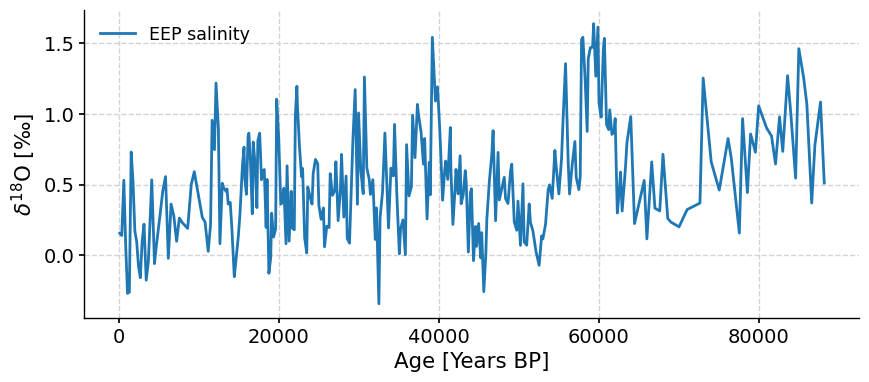

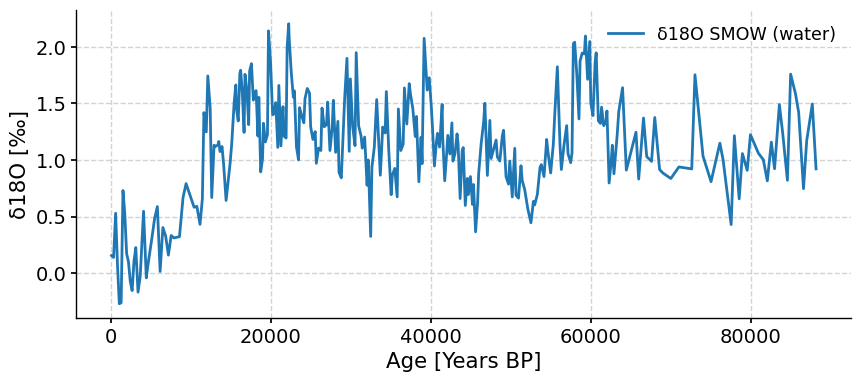

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>)

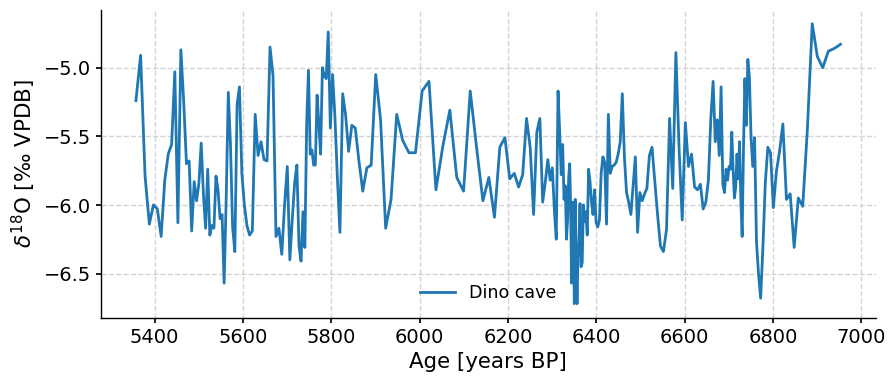

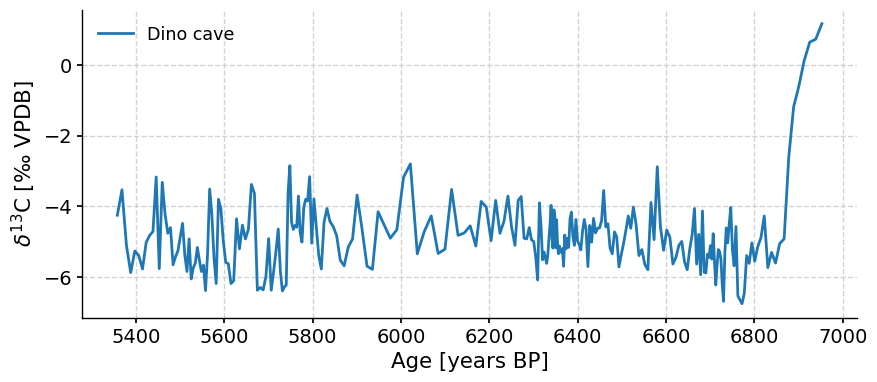

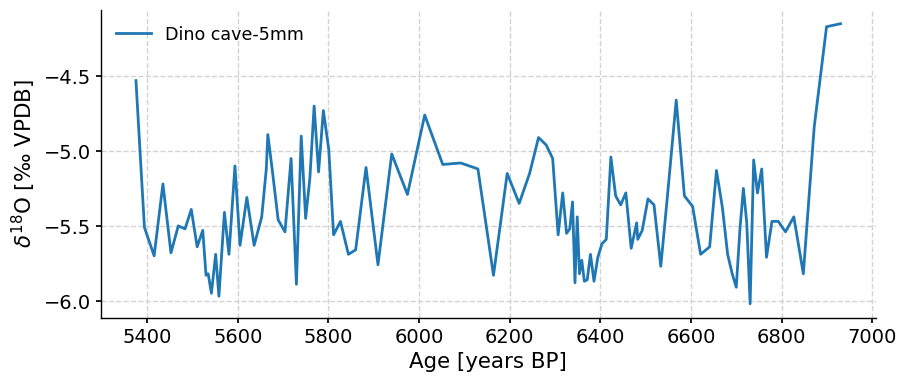

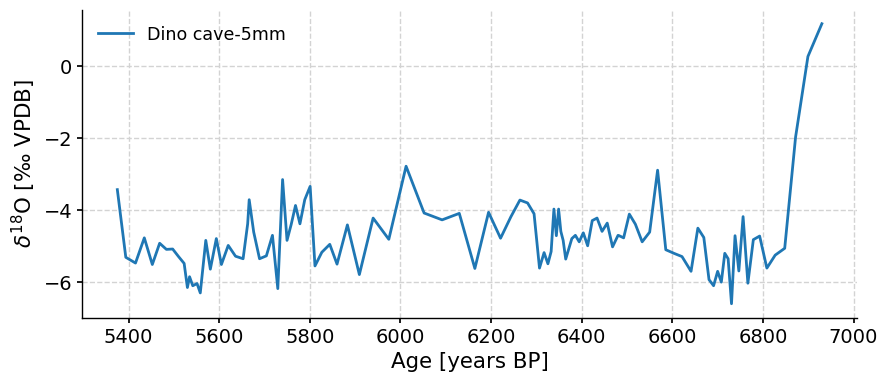

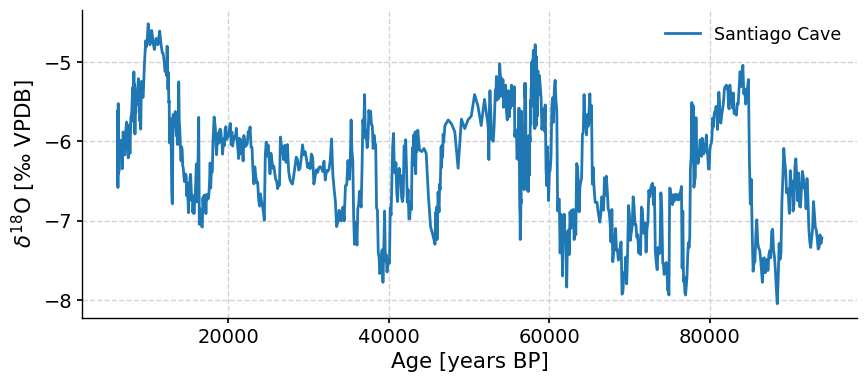

In [28]:
ts_din2Oxy.plot()
ts_din2Carb.plot()

ts_din5Oxy.plot()
ts_din5Carb.plot()

ts_sant.plot()

<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{13}$C [‰ VPDB]'>

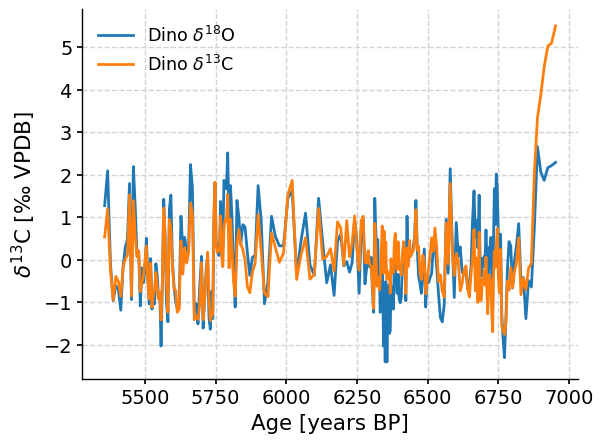

In [24]:
fig, ax=plt.subplots()
ts_din2Oxy.standardize().plot(ax=ax, label='Dino $\delta^{18}$O')
ts_din2Carb.standardize().plot(ax=ax, label='Dino $\delta^{13}$C')

<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

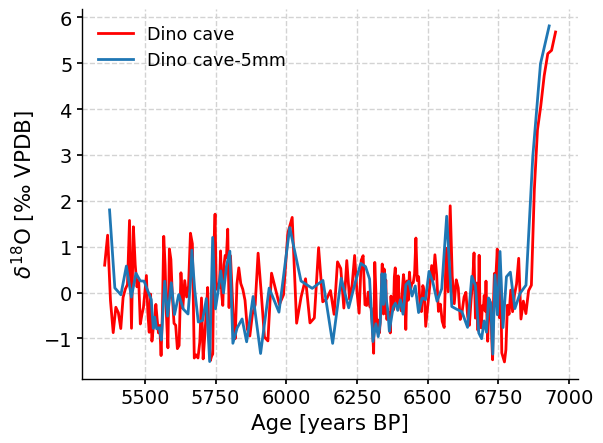

In [25]:
fig, ax=plt.subplots()
ts_din2Carb.detrend().standardize().plot(ax=ax, color='red')
ts_din5Carb.detrend().standardize().plot(ax=ax)

<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

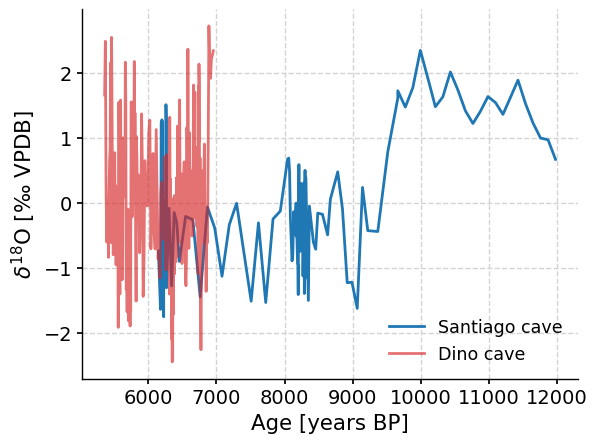

In [32]:
fig, ax=plt.subplots()
ts_sant.sel(time=slice(6000,12000)).detrend().standardize().plot(ax=ax, color='tab:blue')
ts_din2Oxy.detrend().standardize().plot(ax=ax, color='tab:red', alpha=0.65)

<Axes: xlabel='Age [years BP]', ylabel='$\\delta^{18}$O [‰ VPDB]'>

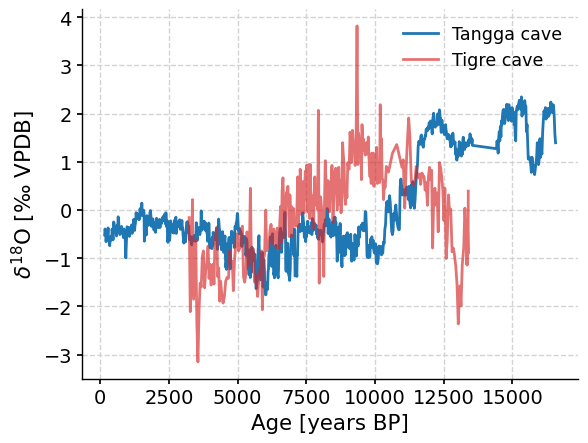

In [42]:
fig, ax=plt.subplots()
ts_tang.standardize().plot(ax=ax, color='tab:blue')
ts_tig.standardize().plot(ax=ax, color='tab:red', alpha=0.65)

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='Scale [yrs]'>)

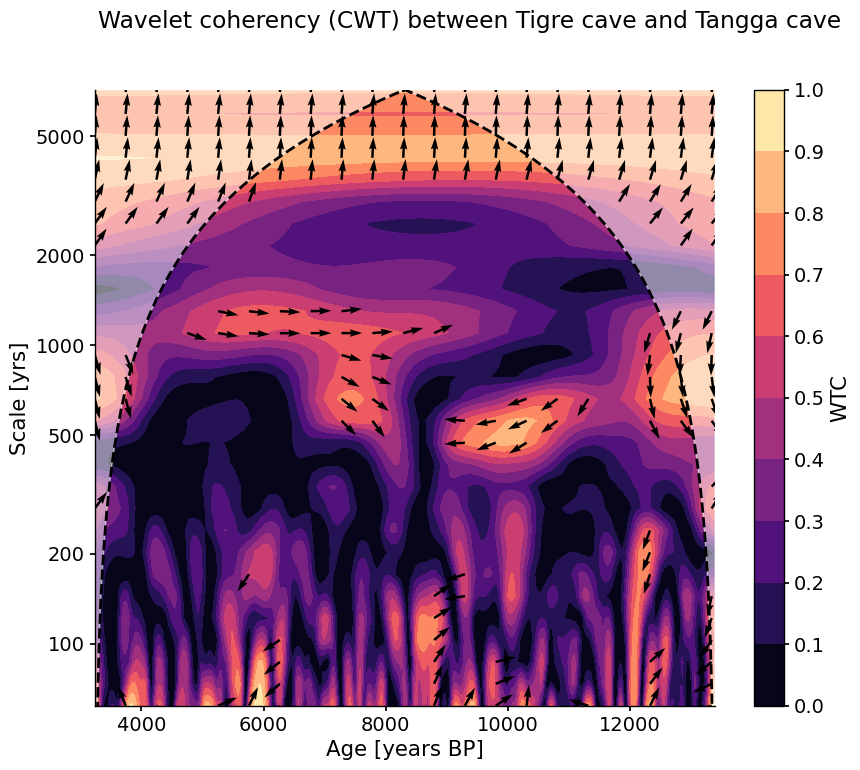

In [43]:
ts_tig.wavelet_coherence(ts_tang).plot()

### Notes

Comparison with Tropical caves to observe if there is a synchrony on the ICTZ shift, as T306 d18O rainwater values seems to show similar pattern like in Ecuador
